# Hybrid Explanation Notebook  

The notebook performs four main functions:

1. **Load the ML Classification Pipeline**  
   It imports a trained traditional ML model and its TF-IDF vectorizer from the thesis directory.  
   These components produce the baseline prediction for each email and serve as the “ground truth”
   explanation source using established XAI methods.

2. **Generate Technical Explanations Using LIME**  
   The Local Interpretable Model-Agnostic Explanations (LIME) method is applied to each email
   to highlight which textual features most influenced the ML model’s classification decision.
   LIME provides granular, human-inspectable reasoning that anchors the rest of this notebook.

3. **Produce Natural-Language Explanations via Multiple LLMs**  
   A unified prompt is used to query several LLMs (all accessed through a single OpenRouter API
   client). Each model transforms the LIME technical output into a clear, public-facing explanation.
   This creates a controlled environment for comparing stylistic and communicative differences
   across LLMs.

4. **Evaluate Explanation Readability**  
   Each explanation—whether from the ML-based humanization step or from an LLM—is automatically
   assessed using a readability metric. This allows examination of how accessible and
   user-friendly the generated explanations are across different model families.

5. **How Readability Is Calculated in This Notebook**  
   Readability scoring is handled by the `readability_score()` helper function:
   - If the `textstat` library is installed, the notebook uses the **Flesch Reading Ease** score  
     (0–100 scale where higher = easier to understand).
   - If `textstat` is unavailable, a custom fallback metric is used.  
     This heuristic evaluates average sentence length and the proportion of short words to estimate  
     readability. Shorter sentences and more short words increase the score.

   These readability values are stored for each provider and visualized in the summary table  
   and the final bar chart, enabling comparison of explanation clarity across model families.

In [1]:
# Imports & environment
import os
import re
import joblib
import time
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display  # Add for display()

# LIME
from lime.lime_text import LimeTextExplainer

# OpenAI/OpenRouter
from openai import OpenAI as OR_OpenAI

# typing
from typing import Tuple

# Read project root
try:
    CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    CURRENT_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

# Load .env from project root
env_path = os.path.join(PROJECT_ROOT, ".env")
if os.path.exists(env_path):
    load_dotenv(dotenv_path=env_path)
else:
    print(f"⚠️ .env not found at {env_path} — OpenRouter key may be missing")

print("✅ Project root:", PROJECT_ROOT)

✅ Project root: C:\Users\azizf\Desktop\Hybrid_Model


In [2]:
# Load ML model + TF-IDF vectorizer
ML_DIR = os.path.join(PROJECT_ROOT, "ML pipeline")   # folder with space
MODEL_PATH = os.path.join(ML_DIR, "model.pkl")
VECT_PATH = os.path.join(ML_DIR, "tfidf_vectorizer.pkl")

if not os.path.exists(MODEL_PATH) or not os.path.exists(VECT_PATH):
    raise FileNotFoundError(
        f"Model or vectorizer not found. Expected:\n - {MODEL_PATH}\n - {VECT_PATH}"
    )

print("Loading ML model and TF-IDF...")
ml_model = joblib.load(MODEL_PATH)
tfidf = joblib.load(VECT_PATH)
print(f"Loaded ML model: {type(ml_model).__name__}, vectorizer: {type(tfidf).__name__}")

# Helper: produce probabilities Nx2 [legit_prob, phish_prob]
def model_proba_for_texts(model, vectorizer, texts):
    X = vectorizer.transform(texts)
    # prefer predict_proba
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        # If two-class, ensure shape Nx2
        if probs.shape[1] >= 2:
            # If columns correspond to classes [0,1], return as-is
            return probs[:, :2]
    # fallback to decision_function
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if scores.ndim == 1:
            # convert via sigmoid
            ph = 1.0 / (1.0 + np.exp(-scores))
            return np.vstack([1-ph, ph]).T
        else:
            exp_scores = np.exp(scores)
            probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
            return probs[:, :2]
    # last resort uniform
    n = len(texts)
    return np.tile(np.array([0.5, 0.5]), (n, 1))

Loading ML model and TF-IDF...
Loaded ML model: CalibratedClassifierCV, vectorizer: TfidfVectorizer


In [3]:
# Load Phishing_Email.csv
PHISHING_EMAIL_PATH = os.path.join("Phishing_Email.csv")

if not os.path.exists(PHISHING_EMAIL_PATH):
    raise FileNotFoundError(f"Phishing_Email.csv not found at {PHISHING_EMAIL_PATH}")

print("Loading dataset:", PHISHING_EMAIL_PATH)
df = pd.read_csv(PHISHING_EMAIL_PATH, engine="python", on_bad_lines="skip")

# Normalize common column names
if 'Email Text' in df.columns and 'Email Type' in df.columns:
    df = df[['Email Text', 'Email Type']].rename(columns={"Email Text":"email_text","Email Type":"label"})
    df['label'] = df['label'].map({'Phishing Email':1,'Safe Email':0})
elif 'body' in df.columns and 'label' in df.columns:
    df = df[['body','label']].rename(columns={"body":"email_text"})
elif 'text' in df.columns and 'label' in df.columns:
    df = df[['text','label']].rename(columns={"text":"email_text"})
else:
    # fallback: assume first two columns
    if df.shape[1] >= 2:
        df = df.iloc[:, :2]
        df.columns = ['email_text','label']

# Clean dataset
df = df.dropna(subset=['email_text','label']).drop_duplicates(subset=['email_text'])

print(f"✅ Loaded dataset: {len(df)} emails (phish={(df['label']==1).sum()}, legit={(df['label']==0).sum()})")

# Select 5 random emails
np.random.seed(42) 

# Try to get a balanced mix
phishing_count = (df['label']==1).sum()
safe_count = (df['label']==0).sum()

if phishing_count >= 3 and safe_count >= 2:
    # Get 3 phishing and 2 safe
    ph = df[df['label']==1].sample(n=3, random_state=42)
    lg = df[df['label']==0].sample(n=2, random_state=42)
    sample_df = pd.concat([ph, lg]).sample(frac=1, random_state=42).reset_index(drop=True)
elif phishing_count >= 2 and safe_count >= 3:
    # Get 2 phishing and 3 safe
    ph = df[df['label']==1].sample(n=2, random_state=42)
    lg = df[df['label']==0].sample(n=3, random_state=42)
    sample_df = pd.concat([ph, lg]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    # Just get 5 random emails regardless of class
    sample_df = df.sample(n=min(5, len(df)), random_state=42).reset_index(drop=True)

print(f"\n📧 Selected {len(sample_df)} random emails for analysis:")
print(f"   Phishing: {(sample_df['label']==1).sum()}")
print(f"   Safe: {(sample_df['label']==0).sum()}")
print()

for i, r in sample_df.iterrows():
    label_str = 'Phishing' if r['label']==1 else 'Safe'
    preview = r['email_text'][:120].replace('\n', ' ')
    print(f"  [{i+1}] {label_str:8s} | {preview}...")

Loading dataset: Phishing_Email.csv
✅ Loaded dataset: 17534 emails (phish=6558, legit=10976)

📧 Selected 5 random emails for analysis:
   Phishing: 3
   Safe: 2

  [1] Phishing | woww . . 8 o - % off paliourg i can ' t believe this incrediible priicess . . pain relief ( from $ 99 ) ( viicodin , hyd...
  [2] Safe     | On Thursday 05 September 2002 04:10 CET Mike Burger wrote: > Just loaded up SA 2.40 from Theo's RPMs...spamassassin-2.40...
  [3] Phishing | big big big girls heartbeat permitted thump comedy nowise patina diagrammatic crusty catchy edt borosilicate began sylva...
  [4] Phishing | all graphics software available , cheap oem versions . good morning , we we offer latest oem packages of all graphics an...
  [5] Safe     | URL: http://www.newsisfree.com/click/-5,8553538,1440/ Date: Not suppliedViral antibodies are identified in a one-month-o...


In [4]:
print("Running ML predictions (sample) and generating LIME explanations...")

probs = model_proba_for_texts(ml_model, tfidf, sample_df['email_text'].tolist())
sample_df['ml_prob'] = probs[:,1]
sample_df['ml_pred'] = (probs[:,1] >= 0.5).astype(int)

for i,row in sample_df.iterrows():
    print(f" Email {i+1}: ML_pred={'Phish' if row['ml_pred']==1 else 'Legit'} (p={row['ml_prob']:.1%}) True={row['label']}")

explainer = LimeTextExplainer(class_names=["Legit","Phishing"])
lime_explanations = []
for i,row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="LIME"):
    txt = row['email_text']
    exp = explainer.explain_instance(txt, lambda texts: model_proba_for_texts(ml_model, tfidf, texts), num_features=10, num_samples=500)
    formatted = []
    for token, weight in exp.as_list():
        side = "Phishing" if weight > 0 else "Legit"
        formatted.append(f"{token:30s} {weight:+.4f} -> {side}")
    lime_text = "\n".join(formatted)
    lime_explanations.append({'as_list': exp.as_list(), 'formatted': lime_text})
    print(f"\n--- Email {i+1} LIME ---\n{lime_text}\n")

sample_df['lime_explanation'] = lime_explanations
print("✅ LIME explanations ready.")

Running ML predictions (sample) and generating LIME explanations...
 Email 1: ML_pred=Phish (p=99.9%) True=1.0
 Email 2: ML_pred=Legit (p=16.1%) True=0.0
 Email 3: ML_pred=Phish (p=99.0%) True=1.0
 Email 4: ML_pred=Phish (p=99.8%) True=1.0
 Email 5: ML_pred=Phish (p=85.0%) True=0.0


LIME:   0%|          | 0/5 [00:00<?, ?it/s]


--- Email 1 LIME ---
weight                         +0.0274 -> Phishing
i                              -0.0264 -> Legit
paliourg                       +0.0264 -> Phishing
men                            +0.0258 -> Phishing
this                           -0.0256 -> Legit
t                              +0.0245 -> Phishing
pain                           +0.0237 -> Phishing
visit                          +0.0236 -> Phishing
http                           +0.0225 -> Phishing
us                             +0.0208 -> Phishing



LIME:  40%|████      | 2/5 [00:00<00:00,  6.24it/s]


--- Email 2 LIME ---
to                             -0.1670 -> Legit
Mike                           -0.1143 -> Legit
I                              -0.0984 -> Legit
art                            +0.0506 -> Phishing
r                              +0.0498 -> Phishing
email                          +0.0485 -> Phishing
FREE                           +0.0407 -> Phishing
t                              +0.0382 -> Phishing
SA                             +0.0066 -> Phishing
net                            +0.0044 -> Phishing


--- Email 3 LIME ---
remove                         +0.1499 -> Phishing
girls                          +0.0812 -> Phishing
please                         -0.0460 -> Legit
easy                           +0.0425 -> Phishing
began                          +0.0304 -> Phishing
investor                       +0.0230 -> Phishing
crusty                         -0.0225 -> Legit
c                              +0.0195 -> Phishing
mexican                        -0.0135 -> Legit
beve

LIME: 100%|██████████| 5/5 [00:00<00:00,  8.02it/s]


--- Email 4 LIME ---
2004                           +0.0259 -> Phishing
software                       +0.0194 -> Phishing
240                            -0.0127 -> Legit
oem                            +0.0117 -> Phishing
cheap                          +0.0113 -> Phishing
pro                            +0.0090 -> Phishing
cs                             +0.0089 -> Phishing
studio                         +0.0088 -> Phishing
offer                          +0.0073 -> Phishing
photoshop                      +0.0047 -> Phishing


--- Email 5 LIME ---
death                          +0.1717 -> Phishing
toll                           +0.1682 -> Phishing
URL                            -0.1505 -> Legit
http                           +0.1427 -> Phishing
baby                           -0.1247 -> Legit
the                            -0.1044 -> Legit
identified                     +0.0965 -> Phishing
Date                           -0.0907 -> Legit
a                              +0.0682 -> Phishing
N

In [5]:
# OpenRouter client (single API key to call multiple models)
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_KEY:
    print("⚠️ OPENROUTER_API_KEY not found in .env. LLM calls will fail.")
    openrouter_client = None
else:
    try:
        openrouter_client = OR_OpenAI(api_key=OPENROUTER_KEY, base_url="https://openrouter.ai/api/v1")
        print("✅ OpenRouter client configured.")
    except Exception as e:
        openrouter_client = None
        print("⚠️ Failed to create OpenRouter client:", e)


MODEL_IDS = {
    "DeepSeek": "deepseek/deepseek-chat-v3.1",     
    "GPT": "openai/gpt-4.1",                       
    "Claude": "anthropic/claude-3.5-sonnet",            
}

# Thin wrapper — single function to call OpenRouter with chosen model name
def call_openrouter_model(prompt: str, model_id: str, temperature: float = 0.3, timeout: int = 30) -> Tuple[str, str]:
    """
    Calls OpenRouter chat completions using provided model_id.
    Returns (text, status) where status is "ok" or "error".
    """
    if openrouter_client is None:
        return ("❌ OpenRouter client not configured.", "error")
    try:
        resp = openrouter_client.chat.completions.create(
            model=model_id,
            messages=[{"role":"user","content":prompt}],
            temperature=temperature,
            max_tokens=800,
        )
        txt = resp.choices[0].message.content.strip()
        return (txt, "ok")
    except Exception as e:
        return (f"❌ OpenRouter request failed: {e}", "error")

✅ OpenRouter client configured.


In [6]:
# Unified prompt template used for all LLMs
LLM_PROMPT_TEMPLATE = """You are a professional phishing detector and cybersecurity expert.
Explain the following LIME-based technical analysis to a member of the public with ZERO technical knowledge.
Be clear, concise, and friendly.

Tasks:
1) Say why the email was flagged (or not) using the LIME top indicators.
2) Explain top 3 suspicious or safe signals in plain language (no jargon).
3) Provide simple actionable advice (what to do next).

Write in three short paragraphs. Keep it direct and easy to understand.
--- EMAIL PREVIEW ---
{email_preview}
--- LIME TECHNICAL OUTPUT ---
{lime_text}
--- END ---
"""

# Readability scoring helper
def readability_score(text: str) -> float:
    """
    Return a higher-is-easier readability score.
    Prefers textstat.flesch_reading_ease if available, otherwise fallback heuristic.
    """
    try:
        import textstat
        score = textstat.flesch_reading_ease(text)
        # Normalize to a positive scale; Flesch typically 0-100 (higher easier)
        return float(score)
    except Exception:
        # fallback heuristic: shorter sentences and shorter words => easier
        sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
        words = re.findall(r'\w+', text)
        if not words or not sentences:
            return 0.0
        avg_sent = len(words) / len(sentences)
        short_words_pct = sum(1 for w in words if len(w)<=4) / len(words)
        # Compose heuristic: higher is easier
        heuristic = max(0.0, 120 - (avg_sent * 4) + (short_words_pct * 20))
        return float(heuristic)

In [7]:
print("\n" + "="*60)
print("GENERATING LLM EXPLANATIONS")
print("="*60)

providers = list(MODEL_IDS.keys())

# Timing storage for LLM explanations
llm_expl_time_total = {prov: 0.0 for prov in providers}
llm_expl_call_count = {prov: 0 for prov in providers}


# Prepare storage columns
for prov in providers:
    sample_df[f'llm_{prov}_explanation'] = None
    sample_df[f'llm_{prov}_status'] = None
    sample_df[f'llm_{prov}_readability'] = None

# Iterate each email and call each provider
total_calls = len(sample_df) * len(providers)
print(f"\nProcessing {len(sample_df)} emails × {len(providers)} providers = {total_calls} total calls\n")

for i, row in sample_df.iterrows():
    email_preview = row['email_text'][:600].replace('\n', ' ')
    lime_text = row['lime_explanation']['formatted']
    prompt = LLM_PROMPT_TEMPLATE.format(email_preview=email_preview, lime_text=lime_text)
    
    print(f"\n{'='*80}")
    print(f"📧 EMAIL {i+1}")
    print(f"{'='*80}")
    print(f"Preview: {row['email_text'][:150]}...")
    print(f"True Label: {'Phishing' if row['label']==1 else 'Safe'}")
    print(f"ML Prediction: {'Phishing' if row['ml_pred']==1 else 'Safe'} (confidence: {row['ml_prob']:.1%})")
    print(f"{'-'*80}\n")
    
    for prov in providers:
        model_id = MODEL_IDS[prov]
        start_llm = time.perf_counter()

        txt, status = call_openrouter_model(prompt, model_id)
        
        elapsed = time.perf_counter() - start_llm
        llm_expl_time_total[prov] += elapsed
        llm_expl_call_count[prov] += 1

        score = readability_score(txt) if status == "ok" else None
        
        sample_df.at[i, f'llm_{prov}_explanation'] = txt
        sample_df.at[i, f'llm_{prov}_status'] = status
        sample_df.at[i, f'llm_{prov}_readability'] = score
        
        # Print full explanation with formatting
        print(f"🤖 {prov.upper()}")
        print(f"   Status: {status}")
        print(f"   Readability Score: {score:.2f}" if score else "   Readability Score: N/A")
        print(f"\n{txt}\n")
        print(f"{'-'*80}\n")
        
        time.sleep(0.5)  # Rate limiting

print("\n" + "="*60)
print("✅ LLM EXPLANATION GENERATION COMPLETE")
print("="*60)


GENERATING LLM EXPLANATIONS

Processing 5 emails × 3 providers = 15 total calls


📧 EMAIL 1
Preview: woww . . 8 o - % off paliourg i can ' t believe this incrediible priicess . . pain relief ( from $ 99 ) ( viicodin , hydrocodoone , valliium ) men ' s...
True Label: Phishing
ML Prediction: Phishing (confidence: 99.9%)
--------------------------------------------------------------------------------

🤖 DEEPSEEK
   Status: ok
   Readability Score: 67.25

This email was flagged as a phishing attempt because it contains many strong warning signs. LIME, our detection tool, found words like "weight," "paliourg," and "men" to be highly suspicious indicators commonly used in scam emails.

The top reasons this email is dangerous are: 1) It promotes prescription drugs with misspelled names, which is illegal and unsafe. 2) It pressures you with phrases like "you can't find this anywhere" to create a false sense of urgency. 3) It tries to get you to click a strange link to an unfamiliar website.



In [8]:
print("\n" + "="*60)
print("⏱️ LLM EXPLANATION GENERATION TIME (HYBRID ML + LLM)")
print("="*60)

timing_rows = []

for prov in providers:
    total_time = llm_expl_time_total[prov]
    calls = llm_expl_call_count[prov]

    if calls == 0:
        continue

    avg_time = total_time / calls

    timing_rows.append({
        "Provider": prov,
        "Total Time (sec)": total_time,
        "Calls": calls,
        "Avg Time per Explanation (sec)": avg_time,
        "Avg Time per Explanation (ms)": avg_time * 1000
    })

    print(f"\n{prov}")
    print(f"   Total explanation time: {total_time:.2f} sec")
    print(f"   Explanations generated: {calls}")
    print(f"   Avg per explanation:    {avg_time:.2f} sec ({avg_time*1000:.0f} ms)")

timing_df = pd.DataFrame(timing_rows)
display(timing_df)


⏱️ LLM EXPLANATION GENERATION TIME (HYBRID ML + LLM)

DeepSeek
   Total explanation time: 68.28 sec
   Explanations generated: 5
   Avg per explanation:    13.66 sec (13656 ms)

GPT
   Total explanation time: 26.49 sec
   Explanations generated: 5
   Avg per explanation:    5.30 sec (5299 ms)

Claude
   Total explanation time: 32.43 sec
   Explanations generated: 5
   Avg per explanation:    6.49 sec (6487 ms)


,Provider,Total Time (sec),Calls,Avg Time per Explanation (sec),Avg Time per Explanation (ms)
0,DeepSeek,68.280272,5,13.656054,13656.05436
1,GPT,26.494824,5,5.298965,5298.96478
2,Claude,32.434336,5,6.486867,6486.86724


In [9]:
print("Humanizing ML (LIME) outputs...")

def humanize_lime(lime_entry):
    items = lime_entry['as_list'][:6]
    pos = [w for w, wt in items if wt > 0]
    neg = [w for w, wt in items if wt <= 0]
    parts = []
    if pos:
        parts.append("The model flagged these suspicious indicators: " + ", ".join(pos) + ".")
    if neg:
        parts.append("These terms suggested the message is likely safe: " + ", ".join(neg) + ".")
    parts.append("Advice: Do not click unexpected links; verify sender by contacting the service directly.")
    return " ".join(parts)

sample_df['ml_explanation_text'] = sample_df['lime_explanation'].apply(humanize_lime)

# Build results table without ML readability
results = []
for i,row in sample_df.iterrows():
    r = {
        "email_index": i+1,
        "true_label": "Phish" if row['label']==1 else "Legit",
        "ml_pred": "Phish" if row['ml_pred']==1 else "Legit",
        "ml_prob": float(row['ml_prob']),
    }
    for prov in providers:
        r[f"{prov}_status"] = row.get(f'llm_{prov}_status')
        r[f"{prov}_readability"] = row.get(f'llm_{prov}_readability')
    results.append(r)

results_df = pd.DataFrame(results)
results_df

Humanizing ML (LIME) outputs...


,email_index,true_label,ml_pred,ml_prob,DeepSeek_status,DeepSeek_readability,GPT_status,GPT_readability,Claude_status,Claude_readability
0,1,Phish,Phish,0.999339,ok,67.250000,ok,73.480620,ok,71.658915
1,2,Legit,Legit,0.160763,ok,70.515789,ok,70.180036,ok,7.836066
2,3,Phish,Phish,0.989994,ok,66.480974,ok,79.043011,ok,36.259740
3,4,Phish,Phish,0.998120,ok,60.408451,ok,80.603531,ok,36.238095
4,5,Legit,Phish,0.850131,ok,78.721003,ok,66.401361,ok,65.313131


Aggregating readability scores and showing comparison...

📊 Readability Summary by Provider:


,Provider,Mean Readability,Std Dev,Count
0,GPT,73.941712,5.322082,5
1,DeepSeek,68.675243,5.991509,5
2,Claude,43.461189,23.003489,5



✅ Saved: C:\Users\azizf\Desktop\Hybrid_Model\pictures\llm_readability_comparison.png


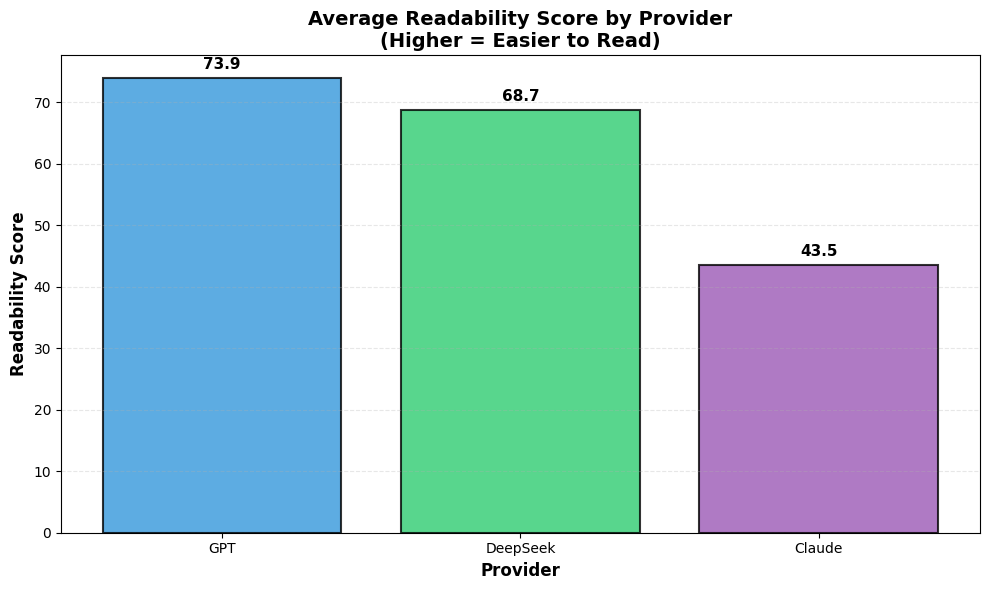


🏆 Top provider by readability: GPT
   Mean score: 73.94
   Std dev: 5.32
   Sample size: 5


In [10]:
print("Aggregating readability scores and showing comparison...\n")

# Compute mean readability per provider
summary = []

for prov in providers:
    col = f"{prov}_readability"
    scores = results_df[col].dropna().astype(float).values if col in results_df.columns else np.array([])
    summary.append({
        "Provider": prov,
        "Mean Readability": float(np.mean(scores)) if len(scores) > 0 else np.nan,
        "Std Dev": float(np.std(scores)) if len(scores) > 0 else np.nan,
        "Count": len(scores)
    })

summary_df = pd.DataFrame(summary).sort_values(by="Mean Readability", ascending=False).reset_index(drop=True)

print("📊 Readability Summary by Provider:")
print("="*60)
display(summary_df)
print("="*60)

# Plot
fig = plt.figure(figsize=(10, 6))
valid_data = summary_df[summary_df['Mean Readability'].notna()]

if len(valid_data) > 0:
    
    colors = ['#3498db', '#2ecc71', '#9b59b6']  # Blue, Green, Purple
    
    bars = plt.bar(valid_data['Provider'], valid_data['Mean Readability'], 
                   color=colors[:len(valid_data)], alpha=0.8, 
                   edgecolor='black', linewidth=1.5)
    
    plt.title("Average Readability Score by Provider\n(Higher = Easier to Read)", 
              fontsize=14, fontweight='bold')
    plt.ylabel("Readability Score", fontsize=12, fontweight='bold')
    plt.xlabel("Provider", fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(valid_data.iterrows()):
        plt.text(i, row['Mean Readability'] + 1, f"{row['Mean Readability']:.1f}", 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    
    # Save to pictures folder
    pictures_dir = os.path.join(PROJECT_ROOT, "pictures")
    os.makedirs(pictures_dir, exist_ok=True)
    output_path = os.path.join(pictures_dir, "llm_readability_comparison.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ Saved: {output_path}")
    
    plt.show()
    
    # Print top provider
    top = valid_data.iloc[0]
    print(f"\n🏆 Top provider by readability: {top['Provider']}")
    print(f"   Mean score: {top['Mean Readability']:.2f}")
    print(f"   Std dev: {top['Std Dev']:.2f}")
    print(f"   Sample size: {int(top['Count'])}")
else:
    print("\n⚠️ No readability scores available")
    print("   Likely causes: OpenRouter key not configured or API errors")